## `photoz_bias.ipynb`

-----------------------

This notebook measures and models the photoz galaxy bias given scale cuts.

In [2]:
import numpy as np 
import importlib
import matplotlib.pyplot as plt
import scipy.interpolate as interp
import scipy.optimize as opt

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator
from pathlib import Path
from scipy.integrate import simpson
from pycorr import TwoPointEstimator

import src.statistics.inference as inference
import src.statistics.combination as comb
import src.statistics.cosmotools as ct
import src.statistics.corrfiles as cf
import src.statistics.sgp as sgp

# Methods:
----------

We use the [Euclid](https://arxiv.org/pdf/2208.10503) approach (derived from Schmidt+2013):

We use : 
$n_{p, m}(z_{j, t})\propto \frac{\bar{\omega}_{\rm{sp},\:m}(r,\:z_{j, t})}{\sqrt{\bar{\omega}_{\rm{ss}}(r,\:z_{j, t})\bar{\omega}_{\rm{pp},\:m}(r)}}$ with $\bar{\omega}_{xy}(r, z_j)=\int_{r_{min}}^{r_{max}}W(r)\omega_{xy}(r, z_j)$ the scale averaged two point correlation function between samples x, y.

- $z_{j, t}$ : center of the fine bin j for the t tracer (ELG, LRG ...)
- $m$ : id of the tomographic bin
- $s$ : spectroscopic sample
- $p$ : photometric sample

Cosmology used (for distances in $h^{-1}Mpc$) :
- $\Omega_c = 0.258868$ (cold dark matter density fraction)
- $\Omega_b = 0.048252$ (baryon density fraction)
- $\Omega_m=\Omega_c+\Omega_b$ (matter density fraction)
- $h = 0.6777$
- $H_0 = h * 100$
- $\sigma_8 = 0.8$
- $n_s = 0.95$

DES Y3 Approach :

-----------------

$n_{p, m}(z_{j, t})\propto\frac{\bar{\omega}_{\rm{sp},\:m}(r,\:z_{j, t})}{\sqrt{\bar{\omega}_{\rm{ss}}(r,\:z_{j, t})\bar{\omega}_{\rm{pp},\:m}(r, z_{j, t})\sigma_j}}$ with $\bar{\omega}_{xy}(r, z_j)=\int_{r_{min}}^{r_{max}}W(r)\omega_{xy}(r, z_j)$

This approach does not really work well due to the very high variations in $\sigma_j$ caused by the photometric method itself (redshift spikes)


In [3]:
ROOT = Path('/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/statistics/outputs/')
bins_hsc = np.arange(0.3, 1.8, 0.3)

markers = ['x', 's', '^', 'D']
linestyles = ['-', '--', '-.', ':']
colormaps = [plt.get_cmap(c) for c in ['Reds', 'Blues', 'Greens', 'Purples']]
colors = [cmap(0.8) for cmap in colormaps]
tracers = ['BGS_ANY', 'LRG', 'ELGnotqso', 'QSO']
tracer_trad = {
    'BGS_ANY' : 'BGS',
    'LRG' : 'LRG',
    'ELGnotqso' : 'ELG',
    'QSO' : 'QSO',
}

In [4]:
stem = 'v12_correction'
path_dictionary = {
    'HSC' : ROOT / stem / f'autos_HSC',
    'DESI_NGC' : ROOT / stem / f'autos_NGC',
    'DESI_SGC' : ROOT / stem / f'autos_SGC',
    'DESIxHSC' : ROOT / stem / f'cross',
}
outdir = ROOT / f'merged_{stem}'
path_dictionary.update({
    'MergedxMerged' : outdir,
    'MergedxHSC' : outdir,
})
assert all([p.exists() for p in path_dictionary.values()])

In [ ]:
importlib.reload(inference)
importlib.reload(comb)
importlib.reload(ct)
importlib.reload(cf)
inference.merge_estimators(
    path_dictionary=path_dictionary, 
    outdir=outdir, 
    verbose=True,
    which_tomo='all'
    )

Processing redshift bin 0 (Completion : 1.79%)
Processing redshift bin 5 (Completion : 10.71%)
Processing redshift bin 10 (Completion : 19.64%)
Processing redshift bin 15 (Completion : 28.57%)
Processing redshift bin 20 (Completion : 37.50%)
Processing redshift bin 25 (Completion : 46.43%)
Processing redshift bin 30 (Completion : 55.36%)
Processing redshift bin 35 (Completion : 64.29%)
Processing redshift bin 40 (Completion : 73.21%)
Processing redshift bin 45 (Completion : 82.14%)
Processing redshift bin 50 (Completion : 91.07%)
Processing redshift bin 55 (Completion : 100.00%)
Saved cross-correlation estimator to /global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/statistics/outputs/merged_v15_dr1/MergedxHSC/MergedxHSC_b1x1_b2x1.npy
Saved cross-correlation estimator to /global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/statistics/outputs/merged_v15_dr1/MergedxHSC/MergedxHSC_b1x1_b2x2.npy
Saved cross-correlation estimator to /global/cfs/projectdirs/desi/users/jchdj/desi-y3-

In [5]:
tracer = 'Merged'
correction_file_reader = cf.CorrFileReader(path_dictionary["HSC"])
bins_z_photo = inference._get_fine_redshift_bins(
    fr=correction_file_reader,
    tracer='HSC'
)
vals_z_photo = (bins_z_photo[:-1] + bins_z_photo[1:]) / 2
correction_file_reader = cf.CorrFileReader(path_dictionary["DESI_NGC"])
bins_z_spectro = inference._get_fine_redshift_bins(
    fr=correction_file_reader,
    tracer='Merged'
)
vals_z_spectro = (bins_z_spectro[:-1] + bins_z_spectro[1:]) / 2

In [6]:
importlib.reload(inference)
importlib.reload(comb)
importlib.reload(ct)
importlib.reload(cf)
nz = []
nz_err = []
scale_cut = [0.5, 3]
for i in range(1, len(bins_z_photo)):
    meas = inference.full_npz_tomo(
        path_dictionary=path_dictionary,
        do_bias_correction=False,
        scale_cuts=scale_cut,
        tracer='Merged',
        tomo_bin=i,
    )
    nz.append(meas[0])
    nz_err.append(meas[1])
nz = np.array(nz)
nz_err = np.array(nz_err)

Using merged method for tracer Merged and tomo bin 1.
Using merged method for tracer Merged and tomo bin 2.
Using merged method for tracer Merged and tomo bin 3.
Using merged method for tracer Merged and tomo bin 4.
Using merged method for tracer Merged and tomo bin 5.
Using merged method for tracer Merged and tomo bin 6.
Using merged method for tracer Merged and tomo bin 7.
Using merged method for tracer Merged and tomo bin 8.
Using merged method for tracer Merged and tomo bin 9.
Using merged method for tracer Merged and tomo bin 10.
Using merged method for tracer Merged and tomo bin 11.
Using merged method for tracer Merged and tomo bin 12.
Using merged method for tracer Merged and tomo bin 13.
Using merged method for tracer Merged and tomo bin 14.
Using merged method for tracer Merged and tomo bin 15.
Using merged method for tracer Merged and tomo bin 16.
Using merged method for tracer Merged and tomo bin 17.
Using merged method for tracer Merged and tomo bin 18.
Using merged method

Text(0, 0.5, 'Number density')

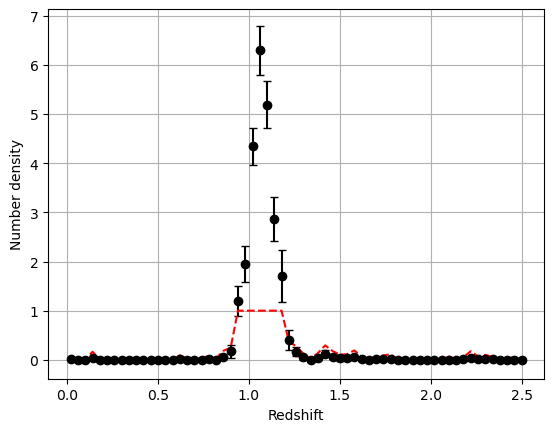

In [8]:
importlib.reload(sgp)
ind = 10
suppresion = sgp.suppression(
    zval=vals_z_photo,
    gp_n=nz[ind],
    gp_sigma=nz_err[ind]
)
mean, uncertainty = sgp.suppress_nz(
    zval=vals_z_spectro,
    gp_n=nz[ind],
    gp_sigma=nz_err[ind]
)
plt.errorbar(
    vals_z_spectro, 
    mean, 
    yerr=uncertainty, 
    fmt='o', 
    color='black', 
    label='Suppressed GP',
    capsize=3
)
plt.plot(
    vals_z_spectro, 
    suppresion, 
    color='red', 
    label='GP',
    linestyle='--'
)
plt.grid()
plt.xlabel('Redshift')
plt.ylabel('Number density')

In [9]:
importlib.reload(sgp)
calib_nz = []
calib_nz_err = []
for ind in range(len(bins_z_photo)-1):
    mean, uncertainty = sgp.suppress_nz(
        zval=vals_z_spectro,
        gp_n=nz[ind],
        gp_sigma=nz_err[ind]
    )
    print(np.sum(mean < 0))
    calib_nz.append(mean)
    calib_nz_err.append(uncertainty)
calib_nz = np.array(calib_nz)
calib_nz_err = np.array(calib_nz_err)

9
2
6
8
4
3
8
5
12
9
7
8
7
8
7
12
8
7
9
10
9
11


Text(0, 0.5, 'Number density')

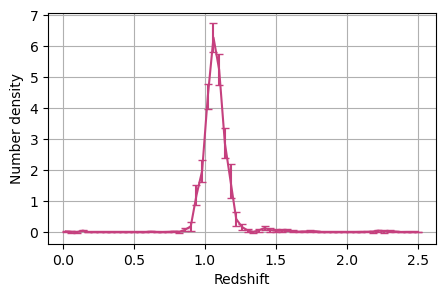

In [11]:
plt.figure(figsize=(5, 3))
colormap = plt.get_cmap('plasma')
for i in range(len(vals_z_photo)):
    if i != 10:
        continue
    plt.errorbar(
        vals_z_spectro, 
        calib_nz[i], 
        yerr=calib_nz_err[i],
        color=colormap(i / (len(vals_z_photo)-1)),
        capsize=3
    )
plt.grid()
plt.xlabel('Redshift')
plt.ylabel('Number density')

In [12]:
vals_z_wdm = np.linspace(0.01, 3, 150)
rp_wdm = np.linspace(scale_cut[0], scale_cut[1], 100)
wdm_values = np.array([
    ct.w_dm(
        rp_vals=rp_wdm,
        z=z,
        integrate=True
        )
    for z in vals_z_wdm
])
wdm_interpolator = interp.interp1d(
    vals_z_wdm, 
    wdm_values, 
    bounds_error=False, 
    fill_value='extrapolate'
)
def integrate_wdm_over_z(zlow, zhigh):
    z_array = np.linspace(zlow, zhigh, 100)
    return np.trapz(
        wdm_interpolator(z_array),
        z_array
    ) / (zhigh - zlow)

In [13]:
wdm = np.array([
    ct.w_dm(
        rp_vals=np.linspace(scale_cut[0], scale_cut[1], 100),
        z=z,
        integrate=True
        )
    for z in vals_z_spectro
])
wdm_phot = np.array([
    ct.w_dm(
        rp_vals=np.linspace(scale_cut[0], scale_cut[1], 100),
        z=z,
        integrate=True
        )
    for z in vals_z_photo
])

In [21]:
corr_factor = []
corr_factor_err = []
dz = vals_z_spectro[1] - vals_z_spectro[0]
dz_phot = vals_z_photo[1] - vals_z_photo[0]
weights_trapz = comb.trapz_weights(vals_z_spectro)

for i in range(len(vals_z_photo)):
    mean, uncertainty = sgp.suppress_nz(
        zval=vals_z_spectro,
        gp_n=nz[i],
        gp_sigma=nz_err[i]
    )
    num = (wdm_phot[i] / dz_phot)
    denom = np.trapz(np.multiply(np.array(mean)**2, wdm), x=vals_z_spectro)
    corr = num / denom
    delta_D = np.sqrt(np.sum((2 * mean * wdm * weights_trapz)**2 * uncertainty**2))
    err = num / (denom**2) * delta_D
    corr_factor.append(corr)
    corr_factor_err.append(err)

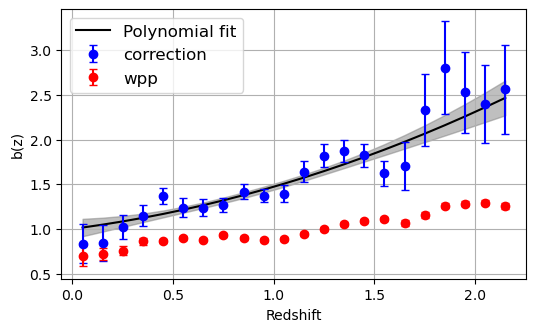

In [22]:
importlib.reload(inference)
importlib.reload(comb)
wpp_scaled = []
wpp_err_scaled = []

for i in range(1, len(vals_z_photo)+1):
    ## now let's get the wpp measurements to get the full correction
    wpp_meas, wpp_err_meas, _ = inference.wpp(
            path=path_dictionary['HSC'],
            scale_cuts=scale_cut,
            bin_index=i,
        )
    wdm_eff = ct.w_dm(
        rp_vals=np.linspace(scale_cut[0], scale_cut[1], 100),
        z=vals_z_photo[i-1],
        integrate=True
    )
    wpp_err_scaled.append(wpp_err_meas*dz_phot/wdm_eff)
    wpp_scaled.append(wpp_meas*dz_phot/wdm_eff)
    
wpp_err_scaled = np.array(wpp_err_scaled)
wpp_scaled = np.array(wpp_scaled)
bpp = np.sqrt(wpp_scaled)
bpp_err = 1/(2* wpp_scaled ** (3/2)) * wpp_err_scaled

errs = comb.combine_error_bars_mult(wpp_scaled, wpp_err_scaled, corr_factor, corr_factor_err)
vals = np.sqrt(np.array(wpp_scaled)*(np.array(corr_factor)))

# polynomial fit to vals and errs
def poly_fit(x, a, b, c):
    return a * x**2 + b * x + c
popt, pcov = opt.curve_fit(
    poly_fit, 
    vals_z_photo, 
    vals,
    sigma=errs, 
    absolute_sigma=True
)
fit_vals = poly_fit(vals_z_photo, *popt)
X = np.vstack([vals_z_photo**2, vals_z_photo, np.ones_like(vals_z_photo)]).T
fit_sigma = np.sqrt(np.sum(X @ pcov * X, axis=1))

plt.figure(figsize=(6, 3.5))
plt.fill_between(
    vals_z_photo, 
    fit_vals - fit_sigma, 
    fit_vals + fit_sigma,
    color='gray', 
    alpha=0.5, 
)
plt.plot(vals_z_photo, fit_vals, color='black', label='Polynomial fit')
plt.errorbar(vals_z_photo, vals, errs, label='correction', capsize=3, fmt='o', color='blue')
plt.errorbar(vals_z_photo, bpp, bpp_err, label='wpp', capsize=3, fmt='o', color='red')
plt.legend(loc='upper left', fontsize=12)
plt.xlabel('Redshift')
plt.ylabel('b(z)')
plt.grid()

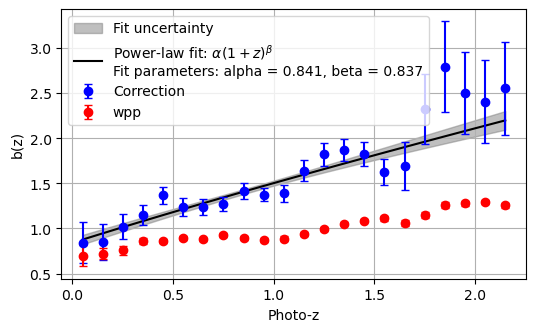

In [15]:
wpp_scaled = []
wpp_err_scaled = []

for i in range(1, len(vals_z_photo)+1):
    wpp_meas, wpp_err_meas, _ = inference.wpp(
        path=path_dictionary['HSC'],
        scale_cuts=scale_cut,
        bin_index=i,
    )
    wdm_eff = ct.w_dm(
        rp_vals=np.linspace(scale_cut[0], scale_cut[1], 100),
        z=vals_z_photo[i-1],
        integrate=True
    )
    wpp_err_scaled.append(wpp_err_meas*dz_phot/wdm_eff)
    wpp_scaled.append(wpp_meas*dz_phot/wdm_eff)

wpp_scaled = np.array(wpp_scaled)
wpp_err_scaled = np.array(wpp_err_scaled)

# Combine errors and compute final correction values
errs = comb.combine_error_bars_mult(wpp_scaled, wpp_err_scaled, corr_factor, corr_factor_err)
vals = np.sqrt(wpp_scaled * corr_factor)
bpp = np.sqrt(wpp_scaled)
bpp_err = 1/(2* wpp_scaled ** (3/2)) * wpp_err_scaled

# --- Power law: alpha * (1 + z)^beta ---
def powerlaw_1pz(z, alpha, beta):
    return alpha * (1 + z) ** beta

# Fit
popt, pcov = opt.curve_fit(powerlaw_1pz, vals_z_photo, vals, sigma=errs, absolute_sigma=True)
fit_vals = powerlaw_1pz(vals_z_photo, *popt)

# --- Uncertainty propagation ---
z = vals_z_photo
alpha, beta = popt
J = np.empty((len(z), 2))
J[:, 0] = (1 + z) ** beta                          # ∂f/∂alpha
J[:, 1] = alpha * (1 + z) ** beta * np.log(1 + z)  # ∂f/∂beta
fit_sigma = np.sqrt(np.sum(J @ pcov * J, axis=1))

plt.figure(figsize=(6, 3.5))
plt.fill_between(z, fit_vals - fit_sigma, fit_vals + fit_sigma, color='gray', alpha=0.5, label='Fit uncertainty')
plt.plot(z, 
         fit_vals, 
         color='black', 
         label='Power-law fit: $\\alpha(1+z)^\\beta$\n' 
         + f'Fit parameters: alpha = {popt[0]:.3f}, beta = {popt[1]:.3f}'
         )
plt.errorbar(z, vals, errs, fmt='o', color='blue', capsize=3, label='Correction')
plt.errorbar(z, bpp, bpp_err, fmt='o', color='red', capsize=3, label='wpp')
plt.xlabel('Photo-z')
plt.ylabel('b(z)')
plt.grid()
plt.legend()

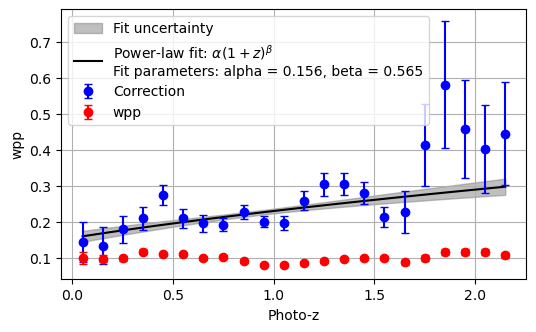

In [26]:
wpp_scaled = []
wpp_err_scaled = []

for i in range(1, len(vals_z_photo)+1):
    wpp_meas, wpp_err_meas, _ = inference.wpp(
        path=path_dictionary['HSC'],
        scale_cuts=scale_cut,
        bin_index=i,
    )
    wpp_err_scaled.append(wpp_err_meas)
    wpp_scaled.append(wpp_meas)

wpp_scaled = np.array(wpp_scaled)
wpp_err_scaled = np.array(wpp_err_scaled)

# Combine errors and compute final correction values
vals = wpp_scaled * corr_factor
errs = np.sqrt((wpp_scaled * corr_factor_err)**2 + (wpp_err_scaled * corr_factor)**2)

def powerlaw_1pz(z, alpha, beta):
    return alpha * (1 + z) ** beta

# Fit
popt, pcov = opt.curve_fit(powerlaw_1pz, vals_z_photo, vals, sigma=errs, absolute_sigma=True)
fit_vals = powerlaw_1pz(vals_z_photo, *popt)

# --- Uncertainty propagation ---
z = vals_z_photo
alpha, beta = popt
J = np.empty((len(z), 2))
J[:, 0] = (1 + z) ** beta                          # ∂f/∂alpha
J[:, 1] = alpha * (1 + z) ** beta * np.log(1 + z)  # ∂f/∂beta
fit_sigma = np.sqrt(np.sum(J @ pcov * J, axis=1))

plt.figure(figsize=(6, 3.5))
plt.fill_between(z, fit_vals - fit_sigma, fit_vals + fit_sigma, color='gray', alpha=0.5, label='Fit uncertainty')
plt.plot(z, 
         fit_vals, 
         color='black', 
         label='Power-law fit: $\\alpha(1+z)^\\beta$\n' 
         + f'Fit parameters: alpha = {popt[0]:.3f}, beta = {popt[1]:.3f}'
         )
plt.errorbar(z, vals, errs, fmt='o', color='blue', capsize=3, label='Correction')
plt.errorbar(z, wpp_scaled, wpp_err_scaled, fmt='o', color='red', capsize=3, label='wpp')
plt.xlabel('Photo-z')
plt.ylabel('wpp')
plt.grid()
plt.legend()

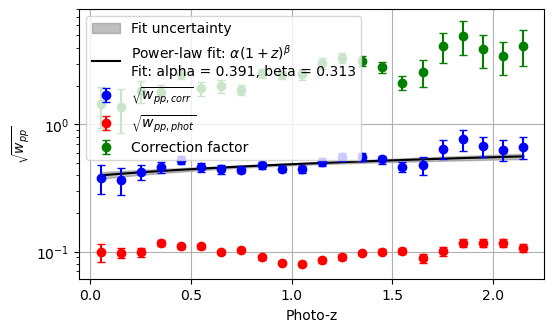

In [29]:
wpp_scaled = []
wpp_err_scaled = []

for i in range(1, len(vals_z_photo)+1):
    wpp_meas, wpp_err_meas, _ = inference.wpp(
        path=path_dictionary['HSC'],
        scale_cuts=scale_cut,
        bin_index=i,
    )
    wpp_err_scaled.append(wpp_err_meas)
    wpp_scaled.append(wpp_meas)

wpp_scaled = np.array(wpp_scaled)
wpp_err_scaled = np.array(wpp_err_scaled)
bpp = np.sqrt(wpp_scaled)
bpp_err = 1/(2* wpp_scaled ** (3/2)) * wpp_err_scaled
vals = np.sqrt(wpp_scaled * corr_factor)
errs = comb.combine_error_bars_mult(wpp_scaled, wpp_err_scaled, corr_factor, corr_factor_err)

def powerlaw_1pz(z, alpha, beta):
    return alpha * (1 + z) ** beta

# Fit
popt, pcov = opt.curve_fit(powerlaw_1pz, vals_z_photo, vals, sigma=errs, absolute_sigma=True)
fit_vals = powerlaw_1pz(vals_z_photo, *popt)

# --- Uncertainty propagation ---
z = vals_z_photo
alpha, beta = popt
J = np.empty((len(z), 2))
J[:, 0] = (1 + z) ** beta                          # ∂f/∂alpha
J[:, 1] = alpha * (1 + z) ** beta * np.log(1 + z)  # ∂f/∂beta
fit_sigma = np.sqrt(np.sum(J @ pcov * J, axis=1))

plt.figure(figsize=(6, 3.5))
plt.fill_between(z, fit_vals - fit_sigma, fit_vals + fit_sigma, color='gray', alpha=0.5, label='Fit uncertainty')
plt.plot(z, 
         fit_vals, 
         color='black', 
         label='Power-law fit: $\\alpha(1+z)^\\beta$\n' 
         + f'Fit: alpha = {popt[0]:.3f}, beta = {popt[1]:.3f}'
         )
plt.errorbar(z, vals, errs, fmt='o', color='blue', capsize=3, label=r'$\sqrt{w_{pp, corr}}$')
plt.errorbar(z, wpp_scaled, wpp_err_scaled, fmt='o', color='red', capsize=3, label=r'$\sqrt{w_{pp, phot}}$')
plt.errorbar(z, corr_factor, corr_factor_err, fmt='o', color='green', capsize=3, label=f'Correction factor')
plt.xlabel('Photo-z')
plt.yscale('log')
plt.ylabel(r'$\sqrt{w_{pp}}$')
plt.grid()
plt.legend()